In [16]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
import itertools #imports

In [2]:
cifar10 = tf.keras.datasets.cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data() #carrega os dados
X_train, X_test = X_train / 255.0, X_test / 255.0 #formata
y_train, y_test = y_train.flatten(), y_test.flatten() #joga pra  vetor
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


/home/voraztitan/miniconda3/envs/numpylib/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [3]:
y_train.shape #shape de y_train

(50000,)

In [4]:
K = len(set(y_train)) 
K #numero de classes pra treino

10

In [6]:
i = Input(shape = X_train[0].shape) #input da rede
x = Conv2D(32, (3,3), strides = 2, activation = 'relu')(i) #camda de convolução
x = Conv2D(64, (3,3), strides = 2, activation = 'relu')(x) #segunda camada de convolucao
x = Conv2D(128, (3,3), strides = 2, activation = 'relu')(x) #terceira camada de convolucao
x = Flatten()(x) #passa pra vetor 
x = Dropout(0.2)(x) #desativa 20% dos neuronios
x = Dense(units = 1024, activation = 'relu')(x) #camada densa da rede neural
x = Dropout(0.2)(x) #mais um dropout
x = Dense(K, activation = 'softmax')(x) #camda de saida 

model = Model(i, x) #define  o modelo

In [7]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']) #compila

In [8]:
r = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 15) #treina

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4473 - loss: 1.5144 - val_accuracy: 0.5472 - val_loss: 1.2670
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5784 - loss: 1.1787 - val_accuracy: 0.6169 - val_loss: 1.0862
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6360 - loss: 1.0227 - val_accuracy: 0.6332 - val_loss: 1.0338
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6835 - loss: 0.8982 - val_accuracy: 0.6693 - val_loss: 0.9435
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7183 - loss: 0.7974 - val_accuracy: 0.6838 - val_loss: 0.9038
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7508 - loss: 0.7057 - val_accuracy: 0.6966 - val_loss: 0.8844
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7797 - loss: 0.6173 - val_accuracy: 0.6980 - val_loss: 0.8867
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8068 - loss: 0.5408 - 

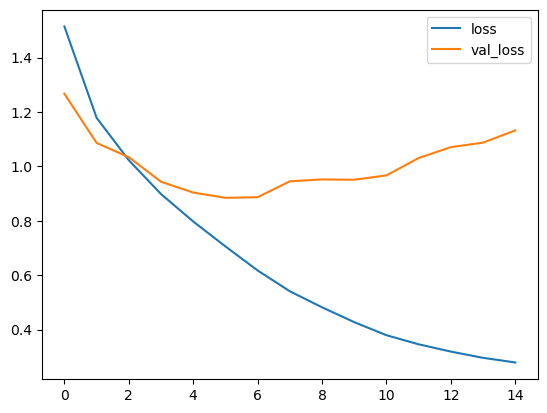

In [9]:
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss') #compara perda com o val_loss
plt.legend()

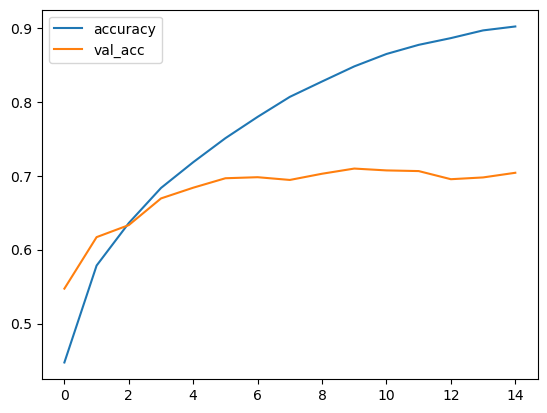

In [10]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc') #compara a acuracia
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion_matrix, without normalization
[[783  26  33  12  18  10  11   5  81  21]
 [ 13 862   6   6   4   2   7   2  36  62]
 [ 65  17 581  64  84  61  72  23  18  15]
 [ 27  21  63 464  60 172 112  32  27  22]
 [ 32  10  71  46 656  34  69  64  15   3]
 [ 11  16  46 168  57 567  45  59  17  14]
 [ 10  11  36  41  31  22 835   3   9   2]
 [ 20   7  37  38  65  61  16 729   6  21]
 [ 65  36   5  10   8   7   4   4 844  17]
 [ 45 143   9  11   7   8  12  11  35 719]]


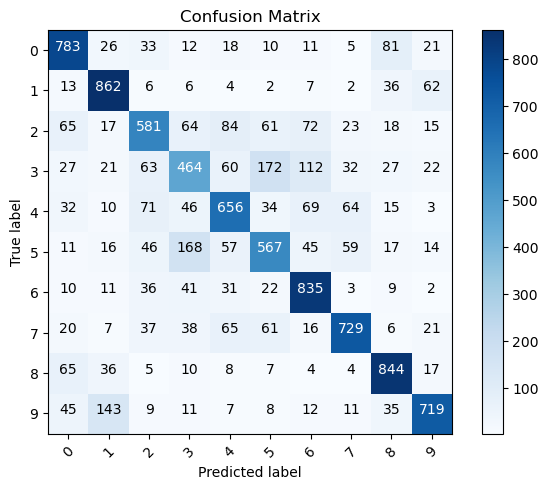

In [11]:
def plot_confusion_matrix(cm, classes, normalize = False, title = 'Confusion Matrix', cmap = plt.cm.Blues): #funcao pra mostrar a matriz de confusao
    if normalize: #se normaliza
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] #joga os valores pra porcentagens
        print('Normalized Confusion Matrix')
    else: 
        print('Confusion_matrix, without normalization')

    print(cm) #mostra os valores 

    plt.imshow(cm, interpolation = 'nearest', cmap = cmap) #define a matriz colorida
    plt.title(title) #titulo
    plt.colorbar() #tons de azul q esta no parametro
    tick_marks = np.arange(len(classes)) #classes
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd' #formatacao do texto
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment='center', color = 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show() #mostra

p_test = model.predict(X_test).argmax(axis = 1) #faz o teste
cm = confusion_matrix(y_test, p_test) #dados
plot_confusion_matrix(cm, list(range(10))) #chama a funcao pra fazer a imagem da matriz

In [13]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split() #separando labels 

Text(0.5, 1.0, 'True label: bird Predicted: dog')

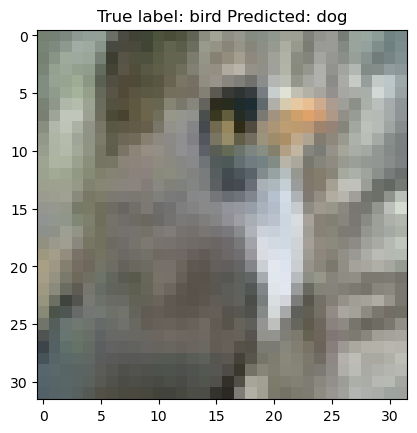

In [15]:
misclassified_idx = np.where(p_test != y_test)[0] #pega os indices onde ele errou
i = np.random.choice(misclassified_idx) #pega um exemplo aleatorio
plt.imshow(X_test[i], cmap = 'gray')  #mostra a foto
plt.title('True label: %s Predicted: %s' % (labels[y_test[i]], labels[p_test[i]]))  #pega exemplos errados igual ao codigo do fashion